In [1]:
import matplotlib.pyplot as plt
import osmnx as ox
import pandas as pd
import geopandas as gpd

In [2]:
bus_stops = ox.features_from_place("Barcelona, Spain",tags = {'highway':'bus_stop'})

In [7]:
metro_stops = ox.features_from_place("Barcelona, Spain",tags = {'railway':'subway_entrance'})
metro_stops

geometry  \
element id                                      
node    26636720     POINT (2.13587 41.38164)   
        71709847     POINT (2.17572 41.40387)   
        191784425    POINT (2.13557 41.38209)   
        191785584    POINT (2.14168 41.38093)   
        191786230    POINT (2.14016 41.38241)   
...                                       ...   
        13686846664  POINT (2.13059 41.39786)   
        13689802320  POINT (2.16771 41.38969)   
        13766822573   POINT (2.16806 41.3862)   
        14011269526  POINT (2.14823 41.37462)   
        14011269529   POINT (2.1482 41.37465)   

                                                            name  \
element id                                                         
node    26636720                          Plaça del Centre (mar)   
        71709847                               Mallorca / Marina   
        191784425                    Plaça del Centre (muntanya)   
        191785584    Pl. Països Catalans / Numància / Ambulatori   
        191786230                                       Numància   
...                                                          ...   
        13686846664                      Via Augusta-Doctor Roux   
        13689802320                 Passeig de Gràcia / Gran Via   
        13766822573                                      Bergara   
        14011269526                                     Gran Via   
        14011269529                                     Gran Via   

                                          name:ca          railway wheelchair  \
element id                                                                      
node    26636720           Plaça del Centre (mar)  subway_entrance         no   
        71709847                              NaN  subway_entrance        yes   
        191784425     Plaça del Centre (muntanya)  subway_entrance        NaN   
        191785584                             NaN  subway_entrance        yes   
        191786230                             NaN  subway_entrance         no   
...                                           ...              ...        ...   
        13686846664       Via Augusta-Doctor Roux  subway_entrance        yes   
        13689802320  Passeig de Gràcia / Gran Via  subway_entrance        yes   
        13766822573                       Bergara  subway_entrance         no   
        14011269526                      Gran Via  subway_entrance         no   
        14011269529                      Gran Via  subway_entrance         no   

                      highway alt_name alt_name:ca  ref  \
element id                                                
node    26636720          NaN      NaN         NaN  NaN   
        71709847          NaN      NaN         NaN  NaN   
        191784425         NaN      NaN         NaN  NaN   
        191785584         NaN      NaN         NaN  NaN   
        191786230         NaN      NaN         NaN  NaN   
...                       ...      ...         ...  ...   
        13686846664  elevator      NaN         NaN  NaN   
        13689802320  elevator      NaN         NaN  NaN   
        13766822573       NaN      NaN         NaN  NaN   
        14011269526       NaN      NaN         NaN  NaN   
        14011269529       NaN      NaN         NaN  NaN   

                    wheelchair:description bicycle level entrance access  \
element id                                                                 
node    26636720                       NaN     NaN   NaN      NaN    NaN   
        71709847                       NaN     NaN   NaN      NaN    NaN   
        191784425                      NaN     NaN   NaN      NaN    NaN   
        191785584                      NaN     NaN   NaN      NaN    NaN   
        191786230                      NaN     NaN   NaN      NaN    NaN   
...                                    ...     ...   ...      ...    ...   
        13686846664                    NaN     NaN   NaN      NaN    NaN   
        

aixo dona totes les entrades, pero tmb nomes dona un punt per parada

In [4]:
tram_stops = ox.features_from_place("Barcelona, Spain",tags = {'railway':'tram_stop'})

In [5]:
subway_network = ox.graph_from_place("Barcelona, Spain", network_type='all', custom_filter='["railway"~"subway"]')
nodes_subway, edges_subway = ox.graph_to_gdfs(subway_network)
edges_subway.reset_index(inplace=True)

In [8]:
edges_subway

,u,v,key,osmid,ref,tunnel,oneway,reversed,length,geometry,name,service
0,462256396,4074264925,0,"[1462897450, 1462897451]",L4,yes,False,False,1932.489240,"LINESTRING (2.19213 41.39518, 2.1937 41.39636,...",NaN,NaN
1,462256402,462256407,0,"[1462897456, 1462897457]",L4,yes,False,False,1310.073065,"LINESTRING (2.21669 41.41176, 2.21735 41.41219...",NaN,NaN
2,462256407,462256402,0,"[1462897456, 1462897457]",L4,yes,False,True,1310.073065,"LINESTRING (2.20967 41.42046, 2.21129 41.41893...",NaN,NaN
3,462256407,8210701384,0,1462897459,L4,yes,True,False,462.733092,"LINESTRING (2.20967 41.42046, 2.20944 41.42066...",NaN,NaN
4,462256413,13398736230,0,"[1463215800, 1462897441]",L4,yes,False,True,714.349923,"LINESTRING (2.17865 41.384, 2.17588 41.38609, ...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
368,13419010983,8274016974,0,"[1462942361, 1462942350]",L11,yes,False,True,1363.507976,"LINESTRING (2.18042 41.45924, 2.18105 41.45929...",L11,NaN
369,13421903889,13401679857,0,1461308266,L2,yes,True,False,494.736614,"LINESTRING (2.1653 41.38705, 2.16489 41.38674,...",NaN,NaN
370,13421903889,13421903895,0,1463215788,NaN,yes,False,False,81.283631,"LINESTRING (2.1653 41.38705, 2.16534 41.38711,...",NaN,crossover
371,13421903895,3397397560,0,1461308267,L2,yes,True,False,1701.972027,"LINESTRING (2.16567 41.38772, 2.16772 41.38921...",NaN,NaN


In [9]:
nodes_subway

,y,x,railway,street_count,ref,geometry
osmid,,,,,,
462256396,41.395176,2.192129,stop,2,NaN,POINT (2.19213 41.39518)
462256402,41.411764,2.216694,stop,2,NaN,POINT (2.21669 41.41176)
462256407,41.420455,2.209669,stop,2,NaN,POINT (2.20967 41.42046)
462256413,41.384003,2.178646,stop,2,NaN,POINT (2.17865 41.384)
462256423,41.406361,2.163171,stop,2,NaN,POINT (2.16317 41.40636)
...,...,...,...,...,...,...
13419010975,41.459140,2.179260,switch,3,NaN,POINT (2.17926 41.45914)
13419010981,41.459201,2.179554,switch,3,NaN,POINT (2.17955 41.4592)
13419010983,41.459238,2.180416,switch,3,NaN,POINT (2.18042 41.45924)


In [9]:
edges_subway['ref'].unique()

array(['L4', 'L3', 'L2', 'L5', nan, 'L9N;L10N', 'L11', 'L2-L3'],
      dtype=object)

In [10]:
import pandas as pd

edge_refs = (
    edges_subway[["u", "v", "ref"]]
    .dropna(subset=["ref"])
    .assign(ref=lambda df: df["ref"].astype(str).str.split(";"))
    .explode("ref")
)
edge_refs["ref"] = edge_refs["ref"].str.strip()

node_refs = pd.concat(
    [
        edge_refs[["u", "ref"]].rename(columns={"u": "osmid"}),
        edge_refs[["v", "ref"]].rename(columns={"v": "osmid"}),
    ],
    ignore_index=True,
).dropna(subset=["ref"]).drop_duplicates()

nodes_subway_with_lines = nodes_subway.join(
    node_refs.groupby("osmid")["ref"].agg(lambda values: sorted(set(values))).rename("lines")
)

nodes_subway_with_lines = gpd.GeoDataFrame(nodes_subway_with_lines, geometry="geometry", crs=nodes_subway.crs).reset_index()

In [11]:
nodes_subway_with_lines

,osmid,y,x,railway,street_count,ref,geometry,lines
0,462256396,41.395176,2.192129,stop,2,NaN,POINT (2.19213 41.39518),[L4]
1,462256402,41.411764,2.216694,stop,2,NaN,POINT (2.21669 41.41176),[L4]
2,462256407,41.420455,2.209669,stop,2,NaN,POINT (2.20967 41.42046),[L4]
3,462256413,41.384003,2.178646,stop,2,NaN,POINT (2.17865 41.384),[L4]
4,462256423,41.406361,2.163171,stop,2,NaN,POINT (2.16317 41.40636),[L4]
...,...,...,...,...,...,...,...,...
169,13419010975,41.459140,2.179260,switch,3,NaN,POINT (2.17926 41.45914),[L11]
170,13419010981,41.459201,2.179554,switch,3,NaN,POINT (2.17955 41.4592),[L11]
171,13419010983,41.459238,2.180416,switch,3,NaN,POINT (2.18042 41.45924),[L11]
172,13421903889,41.387052,2.165300,switch,3,NaN,POINT (2.1653 41.38705),[L2]


<Axes: >

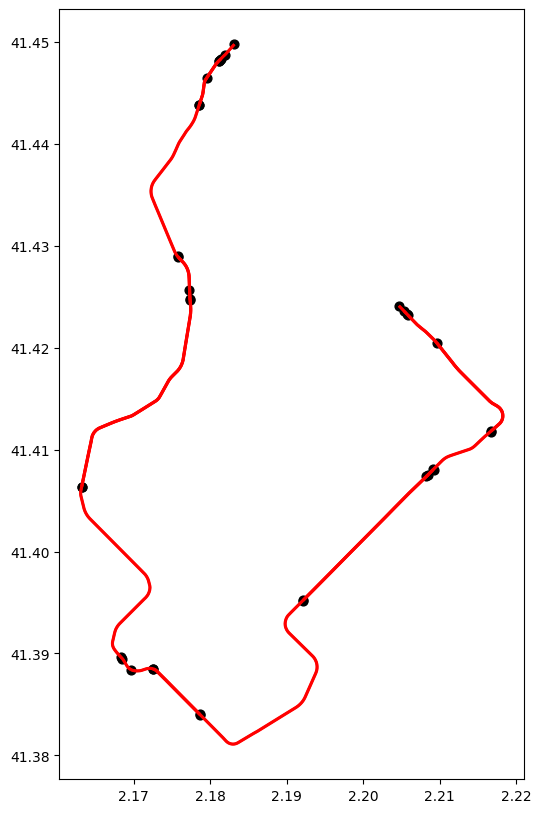

In [12]:
edges_l4 = edges_subway[edges_subway["ref"] == "L4"]
nodes_subway_l4 = nodes_subway_with_lines[nodes_subway_with_lines['lines'].apply(lambda x: 'L4' in x if isinstance(x, list) else False)]
fig, ax = plt.subplots(figsize=(10, 10))
nodes_subway_l4.plot(ax=ax, color="black", markersize=40)
edges_l4.plot(ax=ax, color="red", linewidth=2)

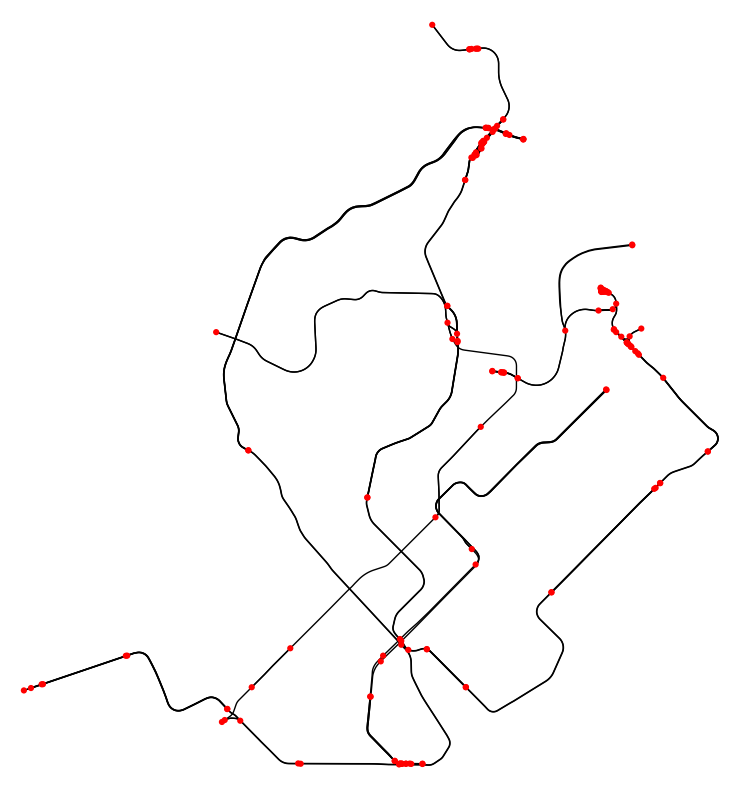

In [13]:
# plot the nodes and edges of the subway network
fig, ax = ox.plot_graph(
    subway_network,
    figsize=(10, 10),
    node_size=20,
    node_color='red',
    edge_color='black',
    edge_linewidth=1,
    bgcolor='white',
    show=False,
    close=False,
 )

In [14]:
# build the tram network graph
tram_network = ox.graph_from_place("Barcelona, Spain", network_type='all', custom_filter='["railway"~"tram"]')
nodes_tram, edges_tram = ox.graph_to_gdfs(tram_network)
nodes_tram

,y,x,railway,street_count,geometry
osmid,,,,,
10976551678,41.419900,2.209349,switch,3,POINT (2.20935 41.4199)
10976551679,41.419846,2.209240,switch,3,POINT (2.20924 41.41985)
3394606129,41.407719,2.193017,NaN,1,POINT (2.19302 41.40772)
3394606130,41.407633,2.192878,switch,1,POINT (2.19288 41.40763)
3394606150,41.408288,2.193894,NaN,2,POINT (2.19389 41.40829)
3394606166,41.408802,2.194490,NaN,2,POINT (2.19449 41.4088)
3670930892,41.418799,2.207777,switch,3,POINT (2.20778 41.4188)
3670930894,41.418864,2.207930,switch,3,POINT (2.20793 41.41886)


In [15]:
bus_filter = (
    '["highway"~"trunk|primary|secondary|tertiary|trunk_link|primary_link|secondary_link"]'
)
bcn_streets = ox.graph_from_place("Barcelona, Spain", network_type='drive_service', simplify=True)

In [16]:
metro_stops

geometry  \
element id                                      
node    26636720     POINT (2.13587 41.38164)   
        71709847     POINT (2.17572 41.40387)   
        191784425    POINT (2.13557 41.38209)   
        191785584    POINT (2.14168 41.38093)   
        191786230    POINT (2.14016 41.38241)   
...                                       ...   
        13686846664  POINT (2.13059 41.39786)   
        13689802320  POINT (2.16771 41.38969)   
        13766822573   POINT (2.16806 41.3862)   
        14011269526  POINT (2.14823 41.37462)   
        14011269529   POINT (2.1482 41.37465)   

                                                            name  \
element id                                                         
node    26636720                          Plaça del Centre (mar)   
        71709847                               Mallorca / Marina   
        191784425                    Plaça del Centre (muntanya)   
        191785584    Pl. Països Catalans / Numància / Ambulatori   
        191786230                                       Numància   
...                                                          ...   
        13686846664                      Via Augusta-Doctor Roux   
        13689802320                 Passeig de Gràcia / Gran Via   
        13766822573                                      Bergara   
        14011269526                                     Gran Via   
        14011269529                                     Gran Via   

                                          name:ca          railway wheelchair  \
element id                                                                      
node    26636720           Plaça del Centre (mar)  subway_entrance         no   
        71709847                              NaN  subway_entrance        yes   
        191784425     Plaça del Centre (muntanya)  subway_entrance        NaN   
        191785584                             NaN  subway_entrance        yes   
        191786230                             NaN  subway_entrance         no   
...                                           ...              ...        ...   
        13686846664       Via Augusta-Doctor Roux  subway_entrance        yes   
        13689802320  Passeig de Gràcia / Gran Via  subway_entrance        yes   
        13766822573                       Bergara  subway_entrance         no   
        14011269526                      Gran Via  subway_entrance         no   
        14011269529                      Gran Via  subway_entrance         no   

                      highway alt_name alt_name:ca  ref  \
element id                                                
node    26636720          NaN      NaN         NaN  NaN   
        71709847          NaN      NaN         NaN  NaN   
        191784425         NaN      NaN         NaN  NaN   
        191785584         NaN      NaN         NaN  NaN   
        191786230         NaN      NaN         NaN  NaN   
...                       ...      ...         ...  ...   
        13686846664  elevator      NaN         NaN  NaN   
        13689802320  elevator      NaN         NaN  NaN   
        13766822573       NaN      NaN         NaN  NaN   
        14011269526       NaN      NaN         NaN  NaN   
        14011269529       NaN      NaN         NaN  NaN   

                    wheelchair:description bicycle level entrance access  \
element id                                                                 
node    26636720                       NaN     NaN   NaN      NaN    NaN   
        71709847                       NaN     NaN   NaN      NaN    NaN   
        191784425                      NaN     NaN   NaN      NaN    NaN   
        191785584                      NaN     NaN   NaN      NaN    NaN   
        191786230                      NaN     NaN   NaN      NaN    NaN   
...                                    ...     ...   ...      ...    ...   
        13686846664                    NaN     NaN   NaN      NaN    NaN   
        

<Axes: >

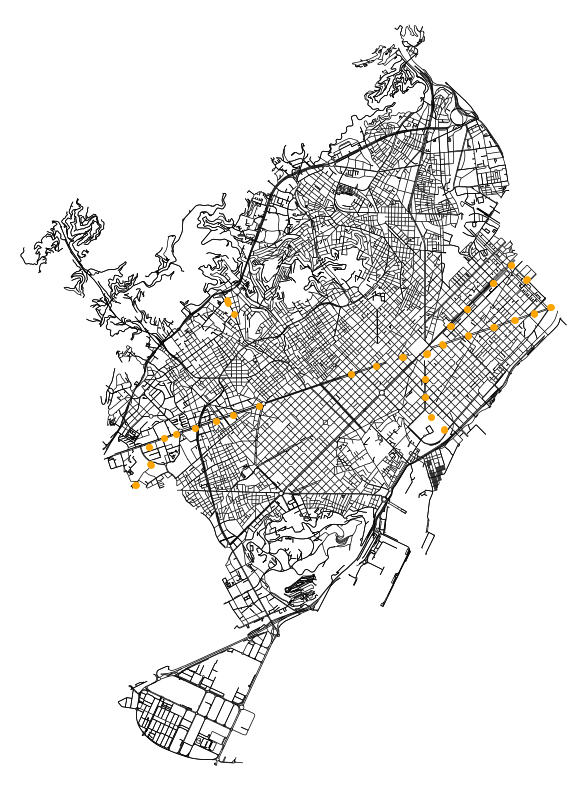

In [17]:
fig, ax = ox.plot_graph(bcn_streets, figsize=(10, 10), node_size=0, edge_color='black', edge_linewidth=0.5, bgcolor='white', show=False, close=False)
# bcn_bus.plot(ax=ax, color='blue', markersize=7, alpha=1)
# metro_stops.plot(ax=ax, color='green', markersize=7, alpha=1)
tram_stops.plot(ax=ax, color='orange', markersize=15, alpha=1)

In [ ]:
# create a graph connecting all the nodes using the strees where a bus could go through

